# Healthcare Prescription Safety & Patient Risk Intelligence Platform

## Data Wrangling & Feature Engineering

### Purpose

This notebook is to:

1. **Clean** the three MIMIC-IV tables (`patients`, `admissions`, `diagnoses_icd`) and the `openfda_events` table, with an explicit plan for missing values and columns to drop.
2. **Merge** the cleaned tables into master dataset(s).
3. **Wrangle / engineer features** needed to answer the four business questions.
4. **Explore (EDA) and visualize** the data to start answering those questions directly.

### Business questions this notebook works toward

1. Which patient groups are at highest risk for readmission?
2. Which diagnoses are most associated with repeat admissions?
3. Which medications have the highest reported adverse events?
4. Can we predict whether a patient will be readmitted?

### 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import ast
import os

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")

import warnings
warnings.filterwarnings("ignore")


### 2. Load Raw Data

In [2]:
RAW = "../Data/Raw"
PROCESSED = "../Data/Processed"

patients = pd.read_csv("../Data/Raw/patients.csv.gz")

admissions = pd.read_csv("../Data/Raw/admissions.csv.gz")

diagnoses = pd.read_csv("../Data/Raw/diagnoses_icd.csv.gz")

fda_events = pd.read_csv("../Data/Raw/openfda_events.csv")

In [3]:
print(f"patients: {patients.shape}")

print(f"admissions: {admissions.shape}")

print(f"diagones: {diagnoses.shape}")

print(f"fda_events: {fda_events.shape}")

patients: (100, 6)
admissions: (275, 16)
diagones: (4506, 5)
fda_events: (100, 39)


### 3. Clean the MIMIC data

#### 3.1 Patients

In [4]:
# Missing values
patients.isnull().sum()

subject_id            0
gender                0
anchor_age            0
anchor_year           0
anchor_year_group     0
dod                  69
dtype: int64

#### Cleaning plan for Patients: 

**Keeping** subject_id, gender and anchor_age (**Key identifiers/features**) 

**Dropping** anchor_year & anchor_year_group (no value for our business questions)

**Converting DOD (date of death)** Convert to deceased flag (0/1) then drop raw date 

In [5]:
patients_clean = patients.copy()

# Create a "dod" flag
patients_clean["deceased"] = patients_clean["dod"].notna().astype(int)

# Drop 
patients_clean = patients_clean.drop(columns=["anchor_year", "anchor_year_group", "dod"])

print(patients_clean.shape)
patients_clean.head()

(100, 4)


,subject_id,gender,anchor_age,deceased
0,10014729,F,21,0
1,10003400,F,72,1
2,10002428,F,80,0
3,10032725,F,38,1
4,10027445,F,48,1


#### 3.2 Admissions

In [6]:
# Missing values

admissions.isnull().sum()

subject_id                0
hadm_id                   0
admittime                 0
dischtime                 0
deathtime               260
admission_type            0
admit_provider_id         0
admission_location        0
discharge_location       42
insurance                 0
language                  0
marital_status           12
race                      0
edregtime                93
edouttime                93
hospital_expire_flag      0
dtype: int64

#### Cleaning plan for Admissions: 

**Keeping** admission_type, admission_location, Insurance, race (**Risk factors for Business Q1**) 

**Dropping** deathtime, admit_provider_id (no value for our business questions)

**Fill with "UNKNOWN"** discharge_location, marital_status, language

**Create "Flag"** edregtime, edouttime (drop raw timestamps) 

**Keep and compute length_of_stay_days** admittime,dischtime (LOS computing readmission timing) 

**Keep and Rename to in_hospital_death** Hospital_expire_flag (Mortality Flag) 

**Engineered readmission target:** by computing a real, standard **30-day readmission flag** — whether a patient was admitted again within 30 days of a given discharge.

In [7]:
admissions_clean = admissions.copy()

# Real datetimes, not strings
date_cols = ["admittime", "dischtime", "edregtime", "edouttime"]
admissions_clean[date_cols] = admissions_clean[date_cols].apply(pd.to_datetime)

# Fill with "UNKNOWN"
admissions_clean["language"] = admissions_clean["language"].replace("?", np.nan).fillna("UNKNOWN")

# Fill with "UNKNOWN"
admissions_clean["discharge_location"] = admissions_clean["discharge_location"].fillna("UNKNOWN")
admissions_clean["marital_status"] = admissions_clean["marital_status"].fillna("UNKNOWN")

# Length of stay (LOS)
admissions_clean["length_of_stay_days"] = (
    (admissions_clean["dischtime"] - admissions_clean["admittime"]).dt.total_seconds() / 86400
).round(2)

# Create a came_via_ed Flag + ed_duration_hours Flag
admissions_clean["came_via_ed"] = admissions_clean["edregtime"].notna().astype(int)
admissions_clean["ed_duration_hours"] = (
    (admissions_clean["edouttime"] - admissions_clean["edregtime"]).dt.total_seconds() / 3600
).round(2)


# Rename in_hospital_death 
admissions_clean["in_hospital_death"] = admissions_clean["hospital_expire_flag"]

# --- Engineer the 30-day readmission target ---
admissions_clean = admissions_clean.sort_values(["subject_id", "admittime"]).reset_index(drop=True)
admissions_clean["prior_admissions_count"] = admissions_clean.groupby("subject_id").cumcount()

admissions_clean["next_admittime"] = admissions_clean.groupby("subject_id")["admittime"].shift(-1)
admissions_clean["days_to_next_admit"] = (
    (admissions_clean["next_admittime"] - admissions_clean["dischtime"]).dt.total_seconds() / 86400
)
admissions_clean["readmitted_30d"] = (
    (admissions_clean["days_to_next_admit"] >= 0) & (admissions_clean["days_to_next_admit"] <= 30)
).astype(int)

# Drop columns
admissions_clean = admissions_clean.drop(
    columns=["admit_provider_id", "deathtime", "edregtime", "edouttime",
             "next_admittime", "hospital_expire_flag"]
)

print(admissions_clean.shape)
admissions_clean.head()

(275, 18)


,subject_id,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,length_of_stay_days,came_via_ed,ed_duration_hours,in_hospital_death,prior_admissions_count,days_to_next_admit,readmitted_30d
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,0.79,1,4.22,0,0,50.050000,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,1.02,1,5.62,0,1,25.740278,1
2,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2.22,1,8.10,0,2,11.242361,1
3,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,EW EMER.,EMERGENCY ROOM,HOSPICE,Medicaid,ENGLISH,WIDOWED,WHITE,1.75,1,4.77,0,3,NaN,0
4,10001217,24597018,2157-11-18 22:56:00,2157-11-25 18:00:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Other,UNKNOWN,MARRIED,WHITE,6.79,1,7.77,0,0,22.956944,1


In [8]:
readmit_rate = admissions_clean["readmitted_30d"].mean()
print(f"30-day readmission rate: {readmit_rate:.1%}  ({admissions_clean['readmitted_30d'].sum()} of {len(admissions_clean)} admissions)")

30-day readmission rate: 19.3%  (53 of 275 admissions)


#### 3.3 Diagnoses_icd

In [9]:
# Missing values

diagnoses.isnull().sum()

subject_id     0
hadm_id        0
seq_num        0
icd_code       0
icd_version    0
dtype: int64

In [10]:
# Duplicates 

print("Diagnoses:", diagnoses.duplicated().sum())

Diagnoses: 0


In [11]:
print("DIAGNOSES")
display(diagnoses.head())

DIAGNOSES


,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10035185,22580999,3,4139,9
1,10035185,22580999,10,V707,9
2,10035185,22580999,1,41401,9
3,10035185,22580999,9,3899,9
4,10035185,22580999,11,V8532,9


In [12]:
diagnoses["icd_code"].value_counts().head(20)

icd_code
4019      68
E785      57
2724      55
E039      47
Z794      37
Z87891    35
42731     34
I2510     33
25000     33
I10       32
F329      32
V1582     31
N179      31
311       30
41401     28
40390     27
E119      26
F419      26
V5867     25
5849      25
Name: count, dtype: int64

In [13]:
top_icd = (
    diagnoses["icd_code"]
    .value_counts()
    .reset_index()
)

top_icd.columns = ["icd_code", "frequency"]

top_icd.head(20)

,icd_code,frequency
0,4019,68
1,E785,57
2,2724,55
3,E039,47
4,Z794,37
5,Z87891,35
6,42731,34
7,I2510,33
8,25000,33
9,I10,32


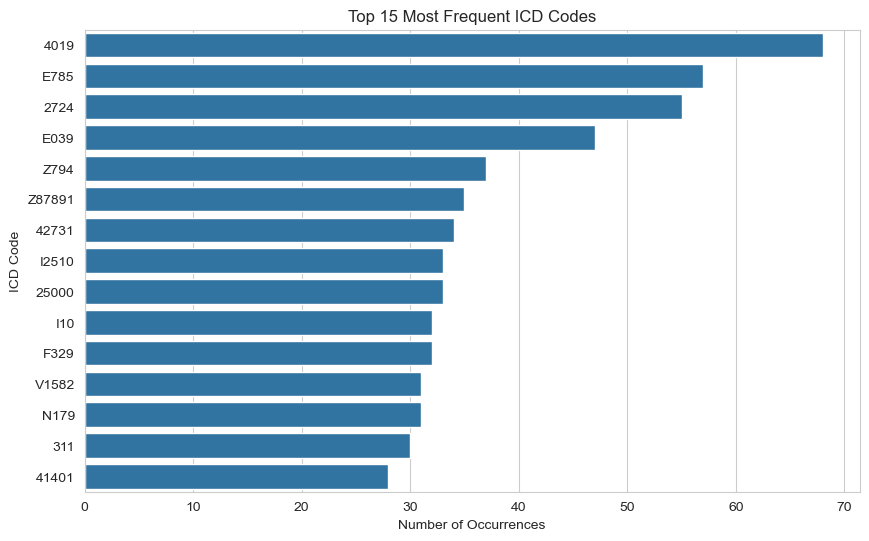

In [14]:
# visualisation

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_icd.head(15),
    x="frequency",
    y="icd_code"
)

plt.title("Top 15 Most Frequent ICD Codes")
plt.xlabel("Number of Occurrences")
plt.ylabel("ICD Code")

plt.show()

#### Cleaning plan for Diagnoses_icd: 

**No Missing values** 

**No Duplicates** 

**Create primary diagnoses Flag** per admission (using `seq_num == 1`)

**Map Clinical categories for common diagnoses** 

**Lookup** for the most common codes only and anything not in the lookup is labeled as `"Other / not mapped"`

In [15]:
ICD_LABELS = {
    # Common chronic / secondary diagnoses (high overall frequency)
    "4019": "Hypertension", "I10": "Hypertension",
    "E785": "Hyperlipidemia", "2724": "Hyperlipidemia",
    "E039": "Hypothyroidism",
    "Z794": "Long-term drug therapy (insulin)",
    "Z87891": "History of nicotine dependence",
    "42731": "Atrial fibrillation", "I4891": "Atrial fibrillation",
    "25000": "Type 2 diabetes", "E119": "Type 2 diabetes",
    "I2510": "Coronary artery disease",
    "F329": "Depressive disorder",
    "N179": "Acute kidney failure",
    "K219": "GERD",
    "Z7901": "Long-term anticoagulant use",
    # Common PRIMARY (principal) diagnoses
    "41401": "Coronary atherosclerosis (native artery)",
    "4241": "Aortic valve disorder",
    "I214": "NSTEMI (heart attack)",
    "99859": "Postoperative infection",
    "5849": "Acute kidney failure",
    "5720": "Liver abscess",
    "42833": "Acute-on-chronic diastolic heart failure",
    "42823": "Acute-on-chronic systolic heart failure",
    "I25110": "Coronary artery disease with angina",
    "A419": "Sepsis, unspecified organism",
    "J9601": "Acute respiratory failure with hypoxia",
    "I5023": "Acute-on-chronic systolic heart failure",
    "34839": "Other encephalopathy",
    "5770": "Acute pancreatitis",
    "03842": "Septicemia (E. coli)",
    "5772": "Pancreatic cyst / pseudocyst",
    "41071": "Subendocardial infarction",
    "4373": "Cerebral aneurysm (nonruptured)",
}

diagnoses_clean = diagnoses.copy()
diagnoses_clean["is_primary_diagnosis"] = (diagnoses_clean["seq_num"] == 1).astype(int)
diagnoses_clean["diagnosis_label"] = diagnoses_clean["icd_code"].map(ICD_LABELS).fillna("Other / not mapped")

print(diagnoses_clean.shape)
diagnoses_clean.head()

(4506, 7)


,subject_id,hadm_id,seq_num,icd_code,icd_version,is_primary_diagnosis,diagnosis_label
0,10035185,22580999,3,4139,9,0,Other / not mapped
1,10035185,22580999,10,V707,9,0,Other / not mapped
2,10035185,22580999,1,41401,9,1,Coronary atherosclerosis (native artery)
3,10035185,22580999,9,3899,9,0,Other / not mapped
4,10035185,22580999,11,V8532,9,0,Other / not mapped


In [16]:
#### Count Diagnoses Per Admission

Do patients with more diagnoses have higher risk?

Object `risk` not found.


In [17]:
diagnosis_count = (
    diagnoses.groupby("hadm_id")
    .size()
    .reset_index(name="diagnosis_count")
)

diagnosis_count.head()

,hadm_id,diagnosis_count
0,20044587,8
1,20093566,32
2,20192635,18
3,20199380,5
4,20214994,36


In [18]:
#### Count Diagnoses Per Patient

In [19]:
patient_diagnosis_count = (
    diagnoses.groupby("subject_id")
    .size()
    .reset_index(name="total_diagnoses")
)

In [20]:
# ICD Distribution 

diagnoses["icd_version"].value_counts()

icd_version
10    2313
9     2193
Name: count, dtype: int64

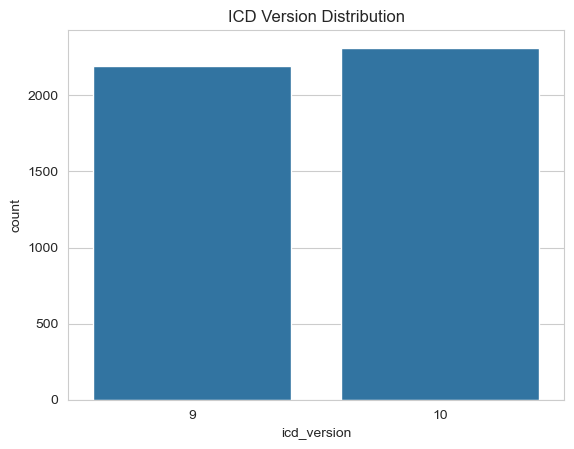

In [21]:
sns.countplot(
    x="icd_version",
    data=diagnoses
)

plt.title("ICD Version Distribution")
plt.show()

In [22]:
# Unique diagnosis

In [23]:
print(
    "Unique ICD Codes:",
    diagnoses["icd_code"].nunique()
)

Unique ICD Codes: 1472


In [24]:
# Primary Diagnosis Analysis

primary_dx = diagnoses[
    diagnoses["seq_num"] == 1
]

primary_dx["icd_code"].value_counts().head(15)

icd_code
41401     7
99859     4
I214      4
4241      4
N179      4
42731     3
I25110    3
A419      3
42833     3
34839     3
42823     3
5720      3
5770      3
5849      3
J9601     3
Name: count, dtype: int64

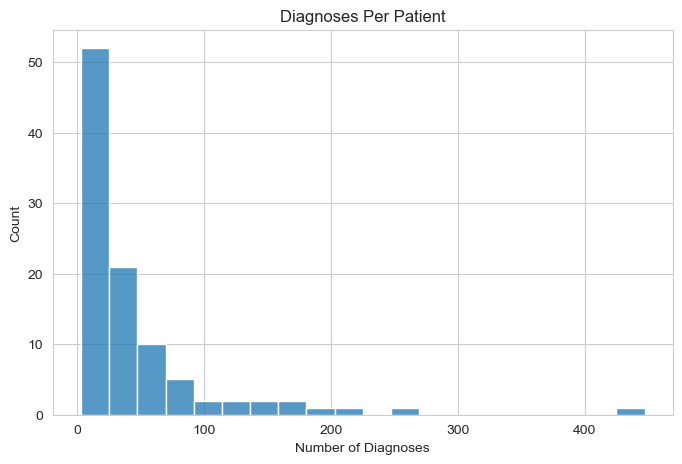

In [25]:
# Disease burden distribution

diagnoses_per_patient = (
    diagnoses.groupby("subject_id")
    .size()
)

plt.figure(figsize=(8,5))

sns.histplot(
    diagnoses_per_patient,
    bins=20
)

plt.title("Diagnoses Per Patient")
plt.xlabel("Number of Diagnoses")

plt.show()

### 4. Create a Clinical Master table

**Diagnoses** has one row per diagnosis code however a single visit can have many diagnoses therefore the same `hadm_id` can appear over and over meanwhile **admissions** has one row per hospital visit (`hadm_id`).

- **First Step** is to transform diagnoses down to one row per `hadm_id`same as **admissions** by diag_agg.
- **Count** how many diagnoses each visit had. groupby("hadm_id") gathers all the diagnosis rows belonging to the same visit into one group, and .agg(diagnosis_count=("icd_code","count")) counts how many are in each group. Result: one row per hadm_id, with a diagnosis_count number.
- Pull out just the primary diagnosis. Each visit has one diagnosis marked as "primary" (is_primary_diagnosis == 1 — the main reason for the visit). This line filters down to only those rows, keeps just hadm_id and the diagnosis name, and renames it to primary_diagnosis. .drop_duplicates() is just a safety net in case a visit somehow had two rows marked primary.
- **Merge** the two pieces together. Now both pieces are one-row-per-hadm_id, so a normal .merge(..., on="hadm_id") lines them up side by side — no duplication risk. Any visit that didn't get a primary_diagnosis match gets filled with "Unknown" instead of a blank.
- Therefore diag_agg, is what then gets attached to admissions_clean in the next cell as the "diagnosis summary" layer of the master table.

In [26]:
diag_agg = diagnoses_clean.groupby("hadm_id").agg(
    diagnosis_count=("icd_code", "count"),
).reset_index()

primary_dx = (
    diagnoses_clean.loc[diagnoses_clean["is_primary_diagnosis"] == 1, ["hadm_id", "diagnosis_label"]]
    .rename(columns={"diagnosis_label": "primary_diagnosis"})
    .drop_duplicates(subset="hadm_id")
)

diag_agg = diag_agg.merge(primary_dx, on="hadm_id", how="left")
diag_agg["primary_diagnosis"] = diag_agg["primary_diagnosis"].fillna("Unknown")

diag_agg.head()

,hadm_id,diagnosis_count,primary_diagnosis
0,20044587,8,Coronary atherosclerosis (native artery)
1,20093566,32,Other / not mapped
2,20192635,18,Other / not mapped
3,20199380,5,Other / not mapped
4,20214994,36,Other / not mapped


In [27]:
clinical_master = (
    admissions_clean
    .merge(patients_clean, on="subject_id", how="left")
    .merge(diag_agg, on="hadm_id", how="left")
)

clinical_master["diagnosis_count"] = clinical_master["diagnosis_count"].fillna(0).astype(int)
clinical_master["primary_diagnosis"] = clinical_master["primary_diagnosis"].fillna("Unknown")

print("clinical_master shape:", clinical_master.shape)
print("\nRemaining missing values:")
print(clinical_master.isnull().sum()[clinical_master.isnull().sum() > 0])
clinical_master.head()

clinical_master shape: (275, 23)

Remaining missing values:
ed_duration_hours      93
days_to_next_admit    100
dtype: int64


,subject_id,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,length_of_stay_days,came_via_ed,ed_duration_hours,in_hospital_death,prior_admissions_count,days_to_next_admit,readmitted_30d,gender,anchor_age,deceased,diagnosis_count,primary_diagnosis
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,0.79,1,4.22,0,0,50.050000,0,F,52,1,8,Other / not mapped
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,1.02,1,5.62,0,1,25.740278,1,F,52,1,8,Other / not mapped
2,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,ENGLISH,WIDOWED,WHITE,2.22,1,8.10,0,2,11.242361,1,F,52,1,13,Other / not mapped
3,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,EW EMER.,EMERGENCY ROOM,HOSPICE,Medicaid,ENGLISH,WIDOWED,WHITE,1.75,1,4.77,0,3,NaN,0,F,52,1,10,Other / not mapped
4,10001217,24597018,2157-11-18 22:56:00,2157-11-25 18:00:00,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Other,UNKNOWN,MARRIED,WHITE,6.79,1,7.77,0,0,22.956944,1,F,55,0,10,Other / not mapped


ed_duration_hours is still missing for the ~34% of admissions that didn't go through the ED — that's expected and correct (there's no ED duration to report), so it's left as NaN rather than imputed with a fake value. days_to_next_admit is NaN for a patient's last admission, for the same reason (there is no next admission).

### 5. Clean & Wrangle the OpenFDA Data

openfda_events.csv is the result of pd.json_normalize() on the raw OpenFDA API response, so it's wide (39 columns) and includes a lot of report-administration metadata that has no analytical value for us, plus two columns (patient.drug, patient.reaction) that are stringified Python lists of dicts — one row can describe several drugs and several reactions at once.

In [28]:
# Missing values

miss = fda_events.isnull().sum().sort_values(ascending=False)
(miss[miss > 0] / len(fda_events) * 100).round(1)

patient.patientdeath.patientdeathdate          100.0
receiver                                       100.0
patient.patientdeath.patientdeathdateformat    100.0
seriousnessdisabling                            98.0
seriousnesslifethreatening                      97.0
seriousnessdeath                                96.0
patient.patientweight                           89.0
seriousnessother                                86.0
patient.summary.narrativeincludeclinical        82.0
seriousnesshospitalization                      79.0
patient.patientagegroup                         41.0
patient.patientonsetageunit                     11.0
patient.patientonsetage                         11.0
occurcountry                                     3.0
receiver.receivertype                            1.0
reportduplicate.duplicatesource                  1.0
safetyreportversion                              1.0
reportduplicate.duplicatenumb                    1.0
sender.sendertype                             

**Cleaning plan for `openfda_events`:**

- **Dropping**: receiver, patient.patientdeath.*, patient.patientweight, patient.summary.narrativeincludeclinical, patient.patientagegroup, transmissiondateformat,receivedateformat,receiptdateformat, companynumb, sender.*, receiver.*, reportduplicate.*, safetyreportversion, duplicate, fulfillexpeditecriteria, reporttype, primarysource.qualification, primarysource.reportercountry.

- **Flag 0/1 + fillna(0)**: seriousnesshospitalization (death/hospitalization/disabling/lifethreatening/other)

- **Explode**: patient.drug, patient.reaction (Business Q3 actual medication and reaction data)

- **Labelling** `1`/`2` codes → `Yes`/`No` and `Male`/`Female`: serious, patient.patientsex

- **Keep**: patient.patientonsetage (real missing data as age wasn't reported; left as `NaN` rather than guessed)

In [29]:
drop_fda_events_cols = [
    "receiver", "patient.patientdeath.patientdeathdateformat", "patient.patientdeath.patientdeathdate",
    "transmissiondateformat", "receivedateformat", "receiptdateformat",
    "companynumb", "sender.senderorganization", "sender.sendertype",
    "receiver.receivertype", "receiver.receiverorganization",
    "reportduplicate.duplicatesource", "reportduplicate.duplicatenumb",
    "safetyreportversion", "duplicate", "fulfillexpeditecriteria", "reporttype",
    "primarysource.qualification", "primarysource.reportercountry",
    "patient.summary.narrativeincludeclinical", "patient.patientweight",
    "patient.patientagegroup",
]
fda_clean = fda_events.drop(columns=[c for c in drop_fda_events_cols if c in fda_events.columns]).copy()

seriousness_cols = [
    "seriousnessdeath", "seriousnesshospitalization", "seriousnessdisabling",
    "seriousnesslifethreatening", "seriousnessother",
]
for c in seriousness_cols:
    fda_clean[c] = fda_clean[c].fillna(0).astype(int)

fda_clean["serious"] = fda_clean["serious"].map({1: "Yes", 2: "No"})
fda_clean = fda_clean.rename(columns={
    "patient.patientsex": "patient_sex",
    "patient.patientonsetage": "patient_age",
    "patient.patientonsetageunit": "patient_age_unit",
})
fda_clean["patient_sex"] = fda_clean["patient_sex"].map({1: "Male", 2: "Female"})

print(fda_clean.shape)
fda_clean.head()

(100, 17)


,safetyreportid,transmissiondate,serious,seriousnessdeath,receivedate,receiptdate,patient_age,patient_age_unit,patient_sex,patient.reaction,patient.drug,primarysourcecountry,seriousnessdisabling,seriousnessother,occurcountry,seriousnesshospitalization,seriousnesslifethreatening
0,5801206-7,20090109,Yes,1,20080707,20080625,26.0,801.0,Male,[{'reactionmeddrapt': 'DRUG ADMINISTRATION ERR...,"[{'drugcharacterization': '1', 'medicinalprodu...",NaN,0,0,NaN,0,0
1,10003300,20141002,Yes,0,20140306,20140306,77.0,801.0,Female,"[{'reactionmeddraversionpt': '17.0', 'reaction...","[{'drugcharacterization': '1', 'medicinalprodu...",US,1,0,NaN,0,0
2,10003301,20141002,Yes,0,20140228,20140228,NaN,NaN,Female,"[{'reactionmeddraversionpt': '17.0', 'reaction...","[{'drugcharacterization': '1', 'medicinalprodu...",US,0,1,NaN,0,0
3,10003302,20141002,No,0,20140312,20140312,NaN,NaN,Male,"[{'reactionmeddraversionpt': '17.0', 'reaction...","[{'drugcharacterization': '1', 'medicinalprodu...",US,0,0,US,0,0
4,10003304,20141212,No,0,20140312,20140424,NaN,NaN,Female,"[{'reactionmeddraversionpt': '17.0', 'reaction...","[{'drugcharacterization': '1', 'medicinalprodu...",US,0,0,US,0,0


### 5.1 Explode the nested drug & reaction fields

`patient.drug` and `patient.reaction` are strings that look like `"[{'medicinalproduct': 'IBUPROFEN', ...}]"` — Python literal reprs of a list of dicts. We parse them with `ast.literal_eval` and explode each report into one row per drug, and one row per reaction, in two separate long-format tables.

In [30]:
def safe_eval(x):
    try:
        return ast.literal_eval(x)
    except Exception:
        return []

drug_rows = []
for _, row in fda_clean[["safetyreportid", "patient.drug"]].iterrows():
    for d in safe_eval(row["patient.drug"]):
        drug_rows.append({
            "safetyreportid": row["safetyreportid"],
            "medicinalproduct": str(d.get("medicinalproduct", "UNKNOWN")).strip().upper(),
            "drugcharacterization": d.get("drugcharacterization"),
            "drugindication": d.get("drugindication"),
            "drugadministrationroute": d.get("drugadministrationroute"),
        })
drug_events = pd.DataFrame(drug_rows)

reaction_rows = []
for _, row in fda_clean[["safetyreportid", "patient.reaction"]].iterrows():
    for r in safe_eval(row["patient.reaction"]):
        reaction_rows.append({
            "safetyreportid": row["safetyreportid"],
            "reaction": str(r.get("reactionmeddrapt", "UNKNOWN")).strip().title(),
        })
reaction_events = pd.DataFrame(reaction_rows)

print("drug_events:", drug_events.shape)
print("reaction_events:", reaction_events.shape)
drug_events.head()

drug_events: (265, 5)
reaction_events: (247, 2)


,safetyreportid,medicinalproduct,drugcharacterization,drugindication,drugadministrationroute
0,5801206-7,DURAGESIC-100,1,DRUG ABUSE,041
1,10003300,BONIVA,1,OSTEOPOROSIS,042
2,10003301,IBUPROFEN,1,PRODUCT USED FOR UNKNOWN INDICATION,NaN
3,10003302,LYRICA,1,NaN,NaN
4,10003304,DOXYCYCLINE HYCLATE,1,NaN,NaN


### 5.2 Build the Medication Adverse-Event Master Table

Grain: **one row per (report × medication × reaction)**. This is intentionally *not* merged with `clinical_master` 

The OpenFDA `drug/event` data pulled in notebook 02 is a **public adverse-event report feed**, keyed on `safetyreportid`. It is **not** linked to these 100 MIMIC patients in any way — there is no shared ID, and OpenFDA reports come from anyone, anywhere, who reported a drug reaction to the FDA.

**There is no real key to merge these two sources on.** Forcing a row-level join between them (e.g. by row position, or a random/fake ID) would fabricate a relationship that doesn't exist in the data and would silently corrupt every downstream analysis.

So this notebook builds **two separate, honest master tables**:

- clinical_master (grain: one row per hospital admission) — powers Q1, Q2 and Q4.
- med_ae_master (grain: one row per medication × reaction reported in an OpenFDA report) — powers Q3.


In [31]:
report_level = fda_clean.drop(columns=["patient.drug", "patient.reaction"])

med_ae_master = (
    drug_events
    .merge(reaction_events, on="safetyreportid", how="left")
    .merge(report_level, on="safetyreportid", how="left")
)

print("med_ae_master shape:", med_ae_master.shape)
med_ae_master.head()

med_ae_master shape: (875, 20)


,safetyreportid,medicinalproduct,drugcharacterization,drugindication,drugadministrationroute,reaction,transmissiondate,serious,seriousnessdeath,receivedate,receiptdate,patient_age,patient_age_unit,patient_sex,primarysourcecountry,seriousnessdisabling,seriousnessother,occurcountry,seriousnesshospitalization,seriousnesslifethreatening
0,5801206-7,DURAGESIC-100,1,DRUG ABUSE,041,Drug Administration Error,20090109,Yes,1,20080707,20080625,26.0,801.0,Male,NaN,0,0,NaN,0,0
1,5801206-7,DURAGESIC-100,1,DRUG ABUSE,041,Overdose,20090109,Yes,1,20080707,20080625,26.0,801.0,Male,NaN,0,0,NaN,0,0
2,10003300,BONIVA,1,OSTEOPOROSIS,042,Vomiting,20141002,Yes,0,20140306,20140306,77.0,801.0,Female,US,1,0,NaN,0,0
3,10003300,BONIVA,1,OSTEOPOROSIS,042,Diarrhoea,20141002,Yes,0,20140306,20140306,77.0,801.0,Female,US,1,0,NaN,0,0
4,10003300,BONIVA,1,OSTEOPOROSIS,042,Arthralgia,20141002,Yes,0,20140306,20140306,77.0,801.0,Female,US,1,0,NaN,0,0


## 6. Exploratory Data Analysis & Visualizations

### Q1 — Which patient groups are at highest risk for readmission?

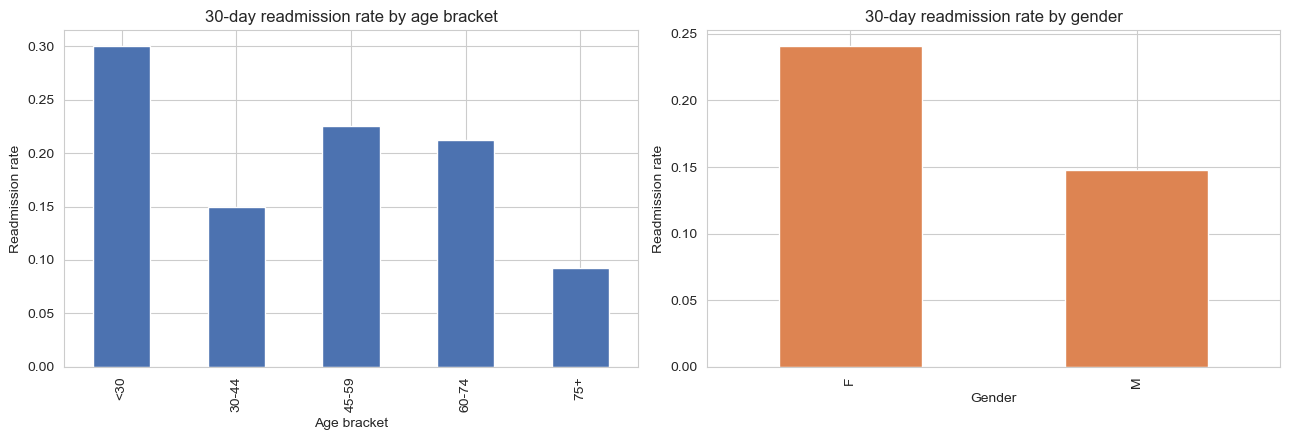

In [32]:
clinical_master["age_bracket"] = pd.cut(
    clinical_master["anchor_age"],
    bins=[0, 30, 45, 60, 75, 100],
    labels=["<30", "30-44", "45-59", "60-74", "75+"],
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

readmit_by_age = clinical_master.groupby("age_bracket")["readmitted_30d"].mean().sort_index()
readmit_by_age.plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("30-day readmission rate by age bracket")
axes[0].set_ylabel("Readmission rate")
axes[0].set_xlabel("Age bracket")

readmit_by_gender = clinical_master.groupby("gender")["readmitted_30d"].mean()
readmit_by_gender.plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("30-day readmission rate by gender")
axes[1].set_ylabel("Readmission rate")
axes[1].set_xlabel("Gender")

plt.tight_layout()
plt.show()

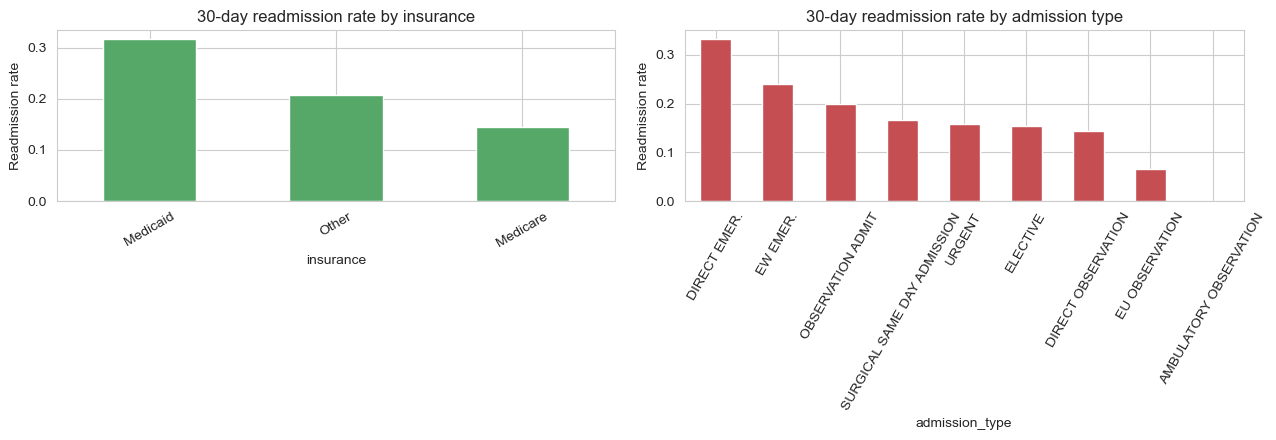

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

readmit_by_ins = clinical_master.groupby("insurance")["readmitted_30d"].mean().sort_values(ascending=False)
readmit_by_ins.plot(kind="bar", ax=axes[0], color="#55A868")
axes[0].set_title("30-day readmission rate by insurance")
axes[0].set_ylabel("Readmission rate")
axes[0].tick_params(axis="x", rotation=30)

readmit_by_type = clinical_master.groupby("admission_type")["readmitted_30d"].mean().sort_values(ascending=False)
readmit_by_type.plot(kind="bar", ax=axes[1], color="#C44E52")
axes[1].set_title("30-day readmission rate by admission type")
axes[1].set_ylabel("Readmission rate")
axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

### Q2 — Which diagnoses are most associated with repeat admissions?

Comparing the primary-diagnosis mix of admissions that led to a 30-day readmission vs. those that didn't.

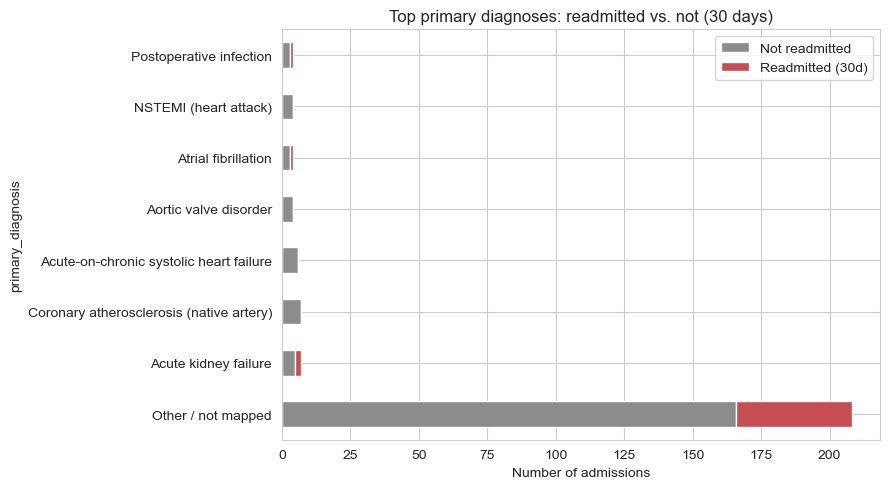

,Not readmitted,Readmitted (30d),readmit_rate
primary_diagnosis,,,
Acute kidney failure,5,2,0.29
Atrial fibrillation,3,1,0.25
Postoperative infection,3,1,0.25
Other / not mapped,166,42,0.20
Coronary atherosclerosis (native artery),7,0,0.00
Acute-on-chronic systolic heart failure,6,0,0.00
Aortic valve disorder,4,0,0.00
NSTEMI (heart attack),4,0,0.00


In [34]:
top_dx = clinical_master["primary_diagnosis"].value_counts().head(8).index

comp = (
    clinical_master[clinical_master["primary_diagnosis"].isin(top_dx)]
    .groupby(["primary_diagnosis", "readmitted_30d"])
    .size()
    .unstack(fill_value=0)
)
comp.columns = ["Not readmitted", "Readmitted (30d)"]
comp = comp.loc[comp.sum(axis=1).sort_values(ascending=False).index]

comp.plot(kind="barh", stacked=True, figsize=(9, 5), color=["#8C8C8C", "#C44E52"])
plt.title("Top primary diagnoses: readmitted vs. not (30 days)")
plt.xlabel("Number of admissions")
plt.tight_layout()
plt.show()

comp["readmit_rate"] = (comp["Readmitted (30d)"] / (comp["Readmitted (30d)"] + comp["Not readmitted"])).round(2)
comp.sort_values("readmit_rate", ascending=False)

### Q3 — Which medications have the highest reported adverse events?

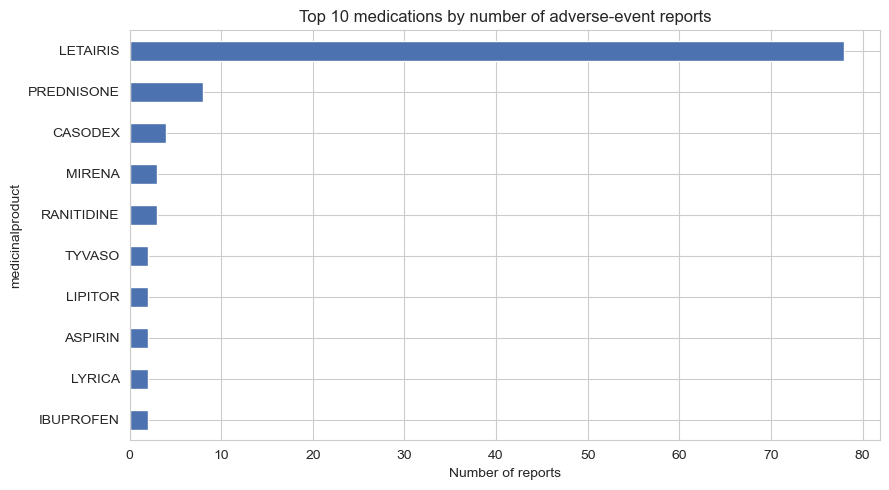

In [35]:
top_meds = drug_events["medicinalproduct"].value_counts().head(10)

plt.figure(figsize=(9, 5))
top_meds.sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Top 10 medications by number of adverse-event reports")
plt.xlabel("Number of reports")
plt.tight_layout()
plt.show()

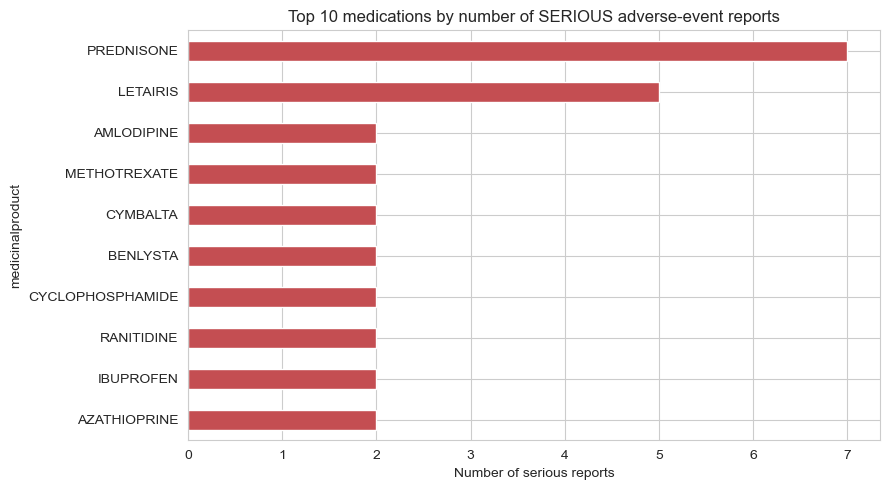

In [36]:
serious_meds = (
    med_ae_master[med_ae_master["serious"] == "Yes"]
    .groupby("medicinalproduct")["safetyreportid"].nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))
serious_meds.sort_values().plot(kind="barh", color="#C44E52")
plt.title("Top 10 medications by number of SERIOUS adverse-event reports")
plt.xlabel("Number of serious reports")
plt.tight_layout()
plt.show()

### Q4 — Can we predict whether a patient will be readmitted?

running a **quick baseline** to sanity-check, I will work on the full model selection on 05_machine_learning notebook.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report

model_df = clinical_master.copy()

cat_cols = ["gender", "admission_type", "insurance", "marital_status", "race", "came_via_ed", "deceased"]
num_cols = ["anchor_age", "length_of_stay_days", "diagnosis_count", "prior_admissions_count", "in_hospital_death"]

model_df = pd.get_dummies(model_df[cat_cols + num_cols + ["readmitted_30d"]], columns=cat_cols, drop_first=True)

X = model_df.drop(columns=["readmitted_30d"])
y = model_df["readmitted_30d"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)[:, 1]

print(f"Baseline logistic regression — ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["Not readmitted", "Readmitted (30d)"]))

Baseline logistic regression — ROC-AUC: 0.721

                  precision    recall  f1-score   support

  Not readmitted       0.92      0.59      0.72        56
Readmitted (30d)       0.30      0.77      0.43        13

        accuracy                           0.62        69
       macro avg       0.61      0.68      0.58        69
    weighted avg       0.80      0.62      0.66        69



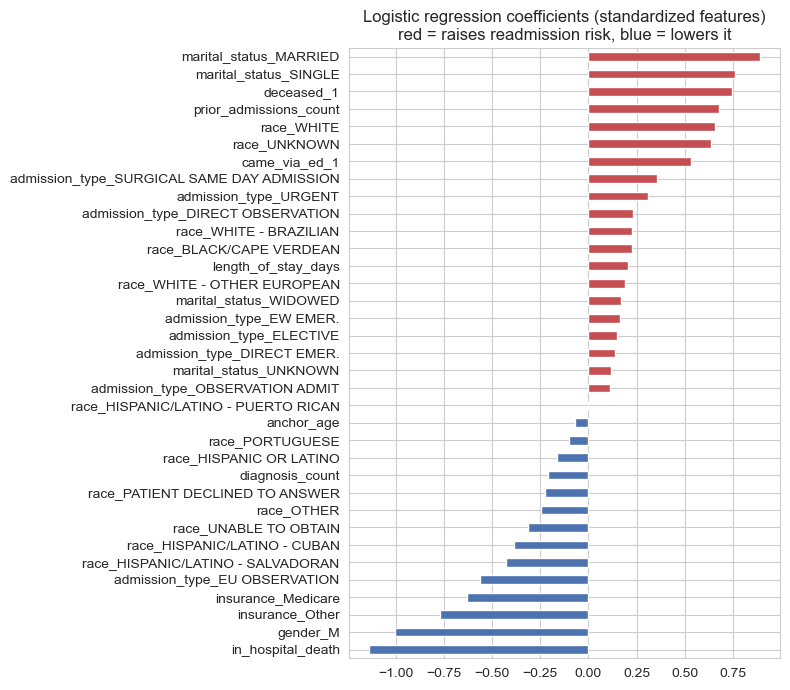

In [38]:
coefs = pd.Series(clf.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(8, 7))
coefs.plot(kind="barh", color=["#C44E52" if v > 0 else "#4C72B0" for v in coefs])
plt.title("Logistic regression coefficients (standardized features)\nred = raises readmission risk, blue = lowers it")
plt.tight_layout()
plt.show()

**Reading this baseline:** with only ~275 admissions this is a small, noisy sample — the ROC-AUC and coefficients above should be read as a first sanity check that there's learnable signal (features clearly move the prediction), not as a production-ready model. A dedicated modeling notebook should try tree-based models, cross-validation, and proper hyperparameter tuning before drawing conclusions.

## 7. Export Master Datasets

In [39]:
import os
os.makedirs(PROCESSED, exist_ok=True)

clinical_master.to_csv(f"{PROCESSED}/clinical_master.csv", index=False)
med_ae_master.to_csv(f"{PROCESSED}/med_adverse_event_master.csv", index=False)
drug_events.to_csv(f"{PROCESSED}/openfda_drug_events_long.csv", index=False)
reaction_events.to_csv(f"{PROCESSED}/openfda_reaction_events_long.csv", index=False)

patients_clean.to_csv(f"{PROCESSED}/patients_clean.csv", index=False)
admissions_clean.to_csv(f"{PROCESSED}/admissions_clean.csv", index=False)
diagnoses_clean.to_csv(f"{PROCESSED}/diagnoses_clean.csv", index=False)
fda_clean.to_csv(f"{PROCESSED}/openfda_events_clean.csv", index=False)

print("Saved to", PROCESSED)
for f in sorted(os.listdir(PROCESSED)):
    print(" -", f)

Saved to ../Data/Processed
 - .DS_Store
 - admissions_clean.csv
 - clinical_master.csv
 - confusion_matrix_long.csv
 - diagnoses_clean.csv
 - feature_importance_long.csv
 - med_adverse_event_master.csv
 - model_comparison_long.csv
 - openfda_drug_events_long.csv
 - openfda_events_clean.csv
 - openfda_reaction_events_long.csv
 - patients_clean.csv
 - readmission_model.pkl
 - readmission_model_features.pkl
 - readmission_scaler.pkl


## Summary of this notebook


- Cleaned `patients`, `admissions`, `diagnoses_icd` and `openfda_events` with an explicit, documented rationale for every dropped column and every missing-value decision (see the tables above).
- Engineered a real **30-day readmission** target from admission timestamps (not just "more than one visit ever").
- Built **`clinical_master`** (275 rows, one per admission) for Q1, Q2 and Q4.
- Exploded the nested OpenFDA `drug`/`reaction` fields and built **`med_ae_master`** for Q3.
- First-pass EDA and visualizations for all four business questions, plus a baseline classifier for Q4.